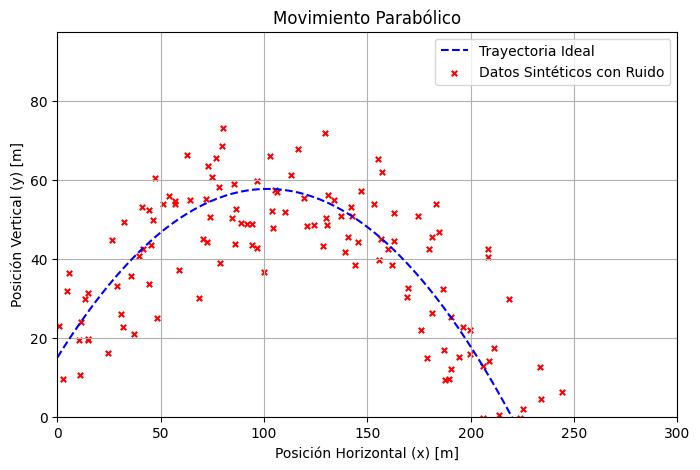


Velocidad Inicial: 45.0 m/s
Ángulo de Disparo: 40.0°
Posición Inicial: x0 = 0.0 m, y0 = 15.0 m
Desviación Estándar del Ruido: 10.0 m

Primeros 5 puntos de datos con ruido:
Tiempo (s):    [0.         0.05121854 0.10243708 0.15365562 0.20487416]
Posición X (m): [ 0.54698879  0.2797145  10.75311378 10.54956155  2.72657011]
Posición Y (m): [23.050386   -5.42575819 10.54023539 19.47447975  9.61043811]


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Parámetros Iniciales del Movimiento ---
velocidad_inicial = 45.0  # m/s
angulo_grados = 40.0      # grados
gravedad = 9.81           # m/s^2

# Posición inicial
x0 = 0.0   # metros
y0 = 15.0   # metros

# Convertir el ángulo a radianes
angulo_radianes = np.deg2rad(angulo_grados)

# Componentes de la velocidad inicial
v0x = velocidad_inicial * np.cos(angulo_radianes)
v0y = velocidad_inicial * np.sin(angulo_radianes)

# --- Generación de Datos Sintéticos (Tiempo) ---
# Tiempo de vuelo teórico (para definir el rango de tiempo)
tiempo_vuelo = (v0y + np.sqrt(v0y**2 + 2 * gravedad * y0)) / gravedad * 2
num_puntos = 250  # Aumentamos los puntos para un mejor entrenamiento posterior

# Vector de tiempo
t = np.linspace(0, tiempo_vuelo, num_puntos)

# --- Cálculo de la Trayectoria Ideal ---
x_ideal = x0 + v0x * t
y_ideal = y0 + v0y * t - 0.5 * gravedad * t**2

# --- Adición de Ruido Gaussiano (Normal) ---
sigma_ruido = 10.0  # desviación estándar del ruido

# Generar ruido para la posición x e y
ruido_x = np.random.normal(0, sigma_ruido, num_puntos)
ruido_y = np.random.normal(0, sigma_ruido, num_puntos)

# Sumar el ruido a la trayectoria ideal
x_ruido = x_ideal + ruido_x
y_ruido = y_ideal + ruido_y

# --- Visualización de Resultados ---
plt.figure(figsize=(8, 5))

# Trazar la trayectoria ideal
plt.plot(x_ideal, y_ideal, label='Trayectoria Ideal', color='blue', linestyle='--')

# Trazar los datos sintéticos con ruido
plt.scatter(x_ruido, y_ruido, label='Datos Sintéticos con Ruido', color='red', marker='x', s=15)

plt.title('Movimiento Parabólico')
plt.xlabel('Posición Horizontal (x) [m]')
plt.ylabel('Posición Vertical (y) [m]')
plt.ylim(bottom=0)
plt.xlim(left=0, right=300)
plt.grid(True)
plt.legend()
plt.show()

# --- Mostrar los parámetros y un ejemplo de datos ---
print(f"\nVelocidad Inicial: {velocidad_inicial} m/s")
print(f"Ángulo de Disparo: {angulo_grados}°")
print(f"Posición Inicial: x0 = {x0} m, y0 = {y0} m")
print(f"Desviación Estándar del Ruido: {sigma_ruido} m")
print(f"\nPrimeros 5 puntos de datos con ruido:")
print(f"Tiempo (s):    {t[:5]}")
print(f"Posición X (m): {x_ruido[:5]}")
print(f"Posición Y (m): {y_ruido[:5]}")



Pérdida (MSE): 0.00675
Error Absoluto Medio (MAE): 0.06914
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step

Resumen de la arquitectura del modelo:



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,880 (7.35 KB)

 Trainable params: 626 (2.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,254 (4.90 KB)

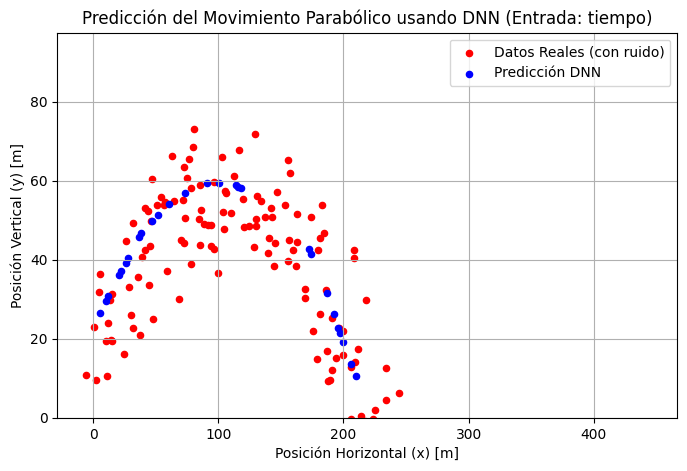

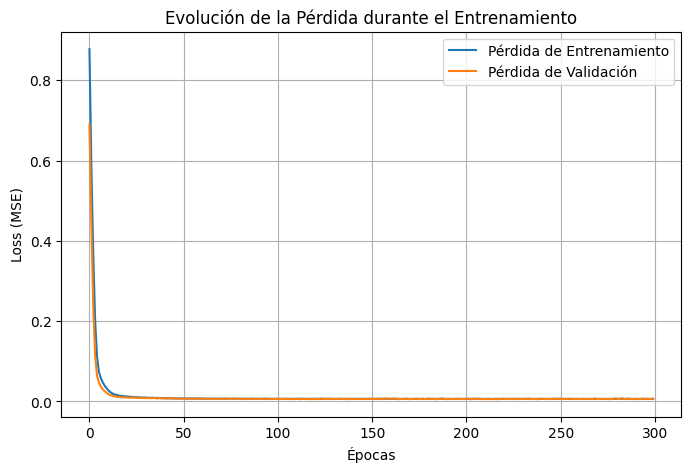

In [18]:
# --- Preparación de datos ---
# Entrada: tiempo (t)
# Salida: posiciones (x, y)
X = t.reshape(-1, 1)
y = np.column_stack((x_ruido, y_ruido))  # matriz de salida con 2 columnas

# --- División en conjuntos de entrenamiento y prueba ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Normalización ---
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# --- Definición del modelo DNN ---
modelo = keras.Sequential([
    layers.Input(shape=(1,)),                # entrada: tiempo t
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    #layers.Dense(64, activation='relu'),
    layers.Dense(2)                          # salida: [x, y]
])

# --- Compilación del modelo ---
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',             # error cuadrático medio
    metrics=['mae']         # error absoluto medio
)

# --- Entrenamiento ---
historial = modelo.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=300,
    batch_size=8,
    verbose=0
)

# --- Evaluación ---
loss, mae = modelo.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"\nPérdida (MSE): {loss:.5f}")
print(f"Error Absoluto Medio (MAE): {mae:.5f}")

# --- Predicción ---
y_pred_scaled = modelo.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# --- Separar las componentes para graficar ---
x_pred = y_pred[:, 0]
y_predicted = y_pred[:, 1]

# --- Información del modelo ---
print("\nResumen de la arquitectura del modelo:\n")
modelo.summary()

# --- Visualización: trayectoria real vs predicha ---
plt.figure(figsize=(8,5))
plt.scatter(x_ruido, y_ruido, label='Datos Reales (con ruido)', color='red', s=20)
plt.scatter(x_pred, y_predicted, label='Predicción DNN', color='blue', s=20)
plt.title('Predicción del Movimiento Parabólico usando DNN (Entrada: tiempo)')
plt.xlabel('Posición Horizontal (x) [m]')
plt.ylabel('Posición Vertical (y) [m]')
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)
plt.show()

# --- Gráfico de pérdida ---
plt.figure(figsize=(8,5))
plt.plot(historial.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(historial.history['val_loss'], label='Pérdida de Validación')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.title('Evolución de la Pérdida durante el Entrenamiento')
plt.legend()
plt.grid(True)
plt.show()


Época 000 | Total: 18.00585 | Datos: 29.64471 | Física: 0.00596 | C.I.: 10.60767
Época 050 | Total: 12.12706 | Datos: 24.24836 | Física: 0.00614 | C.I.: 0.00550
Época 100 | Total: 12.54470 | Datos: 25.07207 | Física: 0.00619 | C.I.: 0.02477
Época 150 | Total: 8.03647 | Datos: 16.04840 | Física: 0.00620 | C.I.: 0.03676
Época 200 | Total: 7.43592 | Datos: 14.85855 | Física: 0.00627 | C.I.: 0.01794
Época 250 | Total: 6.38572 | Datos: 12.76232 | Física: 0.00618 | C.I.: 0.01110
Época 300 | Total: 7.71091 | Datos: 15.40360 | Física: 0.00616 | C.I.: 0.02623
Época 350 | Total: 7.08484 | Datos: 14.15500 | Física: 0.00614 | C.I.: 0.02036
Época 400 | Total: 7.56890 | Datos: 15.12892 | Física: 0.00620 | C.I.: 0.01065
Época 450 | Total: 7.53704 | Datos: 15.06439 | Física: 0.00626 | C.I.: 0.01198
Época 499 | Total: 7.64122 | Datos: 15.27223 | Física: 0.00620 | C.I.: 0.01290

Pesos de las pérdidas:
Datos = 0.2, Física = 0.5, Condiciones Iniciales = 0.3

Resumen del modelo:



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,880 (7.35 KB)

 Trainable params: 626 (2.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,254 (4.90 KB)

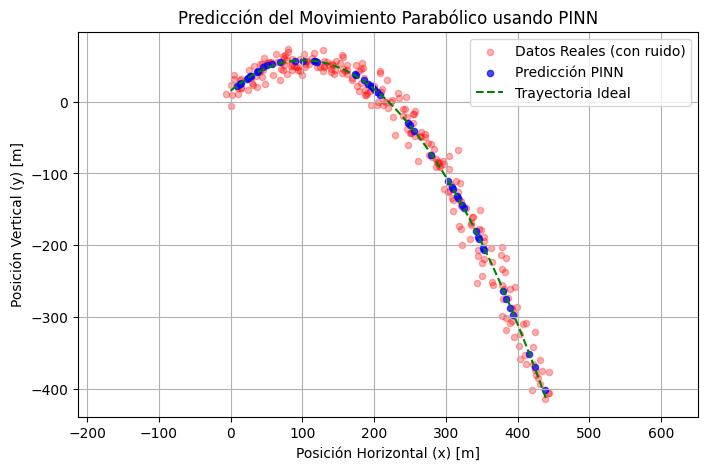

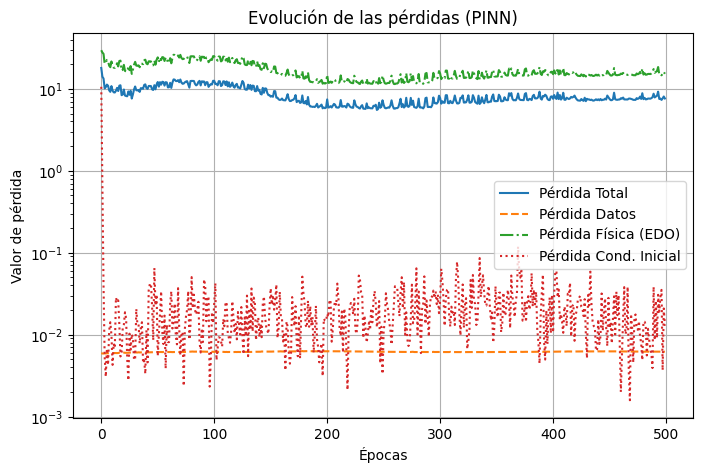

In [19]:
# --- Función de pérdida combinada (Datos + Física + C.I.) ---
lambda_data = 0.2
lambda_physics = 0.5
lambda_ci = 0.3

# Conversión a tensores
X_train_tf = tf.convert_to_tensor(X_train_scaled, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train_scaled, dtype=tf.float32)

# --- Convertir los parámetros del scaler a tensores ---
scale_y = tf.constant(scaler_y.scale_, dtype=tf.float32)
scale_X = tf.constant(scaler_X.scale_, dtype=tf.float32)
mean_y = tf.constant(scaler_y.mean_, dtype=tf.float32)
mean_X = tf.constant(scaler_X.mean_, dtype=tf.float32)

# Usamos los valores numpy del scaler ANTES de que sean tensores simbólicos.
t0_scaled_value = (0.0 - scaler_X.mean_[0]) / scaler_X.scale_[0]

# Crear la constante de TensorFlow FUERA de la función de pérdida.
t0_scaled_tf = tf.constant([[t0_scaled_value]], dtype=tf.float32) # Forma (1, 1)

# --- Definición de la función de pérdida total ---
@tf.function
def loss_total(modelo, X, y):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(X)
        pred = modelo(X)  # [x(t), y(t)] predichos (normalizados)
        dy_dt_scaled = tape.gradient(pred[:, 1], X)  # derivada de y respecto a t (normalizado)

    # === Escalar a unidades reales ===
    y_pred_real = pred * scale_y + mean_y

    # Comprobación de 'dy_dt_scaled' para evitar errores si X tiene un solo elemento
    if dy_dt_scaled is None:
        # Esto puede pasar en el último batch si es de tamaño 1
        # O si hay un problema con el 'watch'
        # Devolvemos un gradiente cero para no parar el entrenamiento
        dy_dt_scaled = tf.zeros_like(X)

    dy_dt_real = dy_dt_scaled * (scale_y[1] / scale_X[0])

    # === Pérdida por datos ===
    mse_datos = tf.reduce_mean(tf.square(y - pred))

    # === Pérdida por residuo físico ===
    t_real = X * scale_X + mean_X
    residuo = dy_dt_real[:, 0] - (v0y - g * t_real[:, 0])
    mse_residuo = tf.reduce_mean(tf.square(residuo))

    # === Pérdida por condición inicial ===
    # Usamos la constante pre-calculada 't0_scaled_tf'
    pred0 = modelo(t0_scaled_tf)
    xy0_real = pred0 * scale_y + mean_y
    ci_loss = tf.reduce_mean(tf.square(xy0_real[0, 0] - x0) + tf.square(xy0_real[0, 1] - y0))

    # === Combinación ponderada ===
    total = lambda_data * mse_datos + lambda_physics * mse_residuo + lambda_ci * ci_loss

    return total, mse_datos, mse_residuo, ci_loss


# --- Entrenamiento manual con mini-batches ---
opt = keras.optimizers.Adam(learning_rate=1e-4)
epochs = 500
batch_size = 8

# Crear dataset en TensorFlow
dataset = tf.data.Dataset.from_tensor_slices((X_train_tf, y_train_tf))
dataset = dataset.shuffle(buffer_size=len(X_train_tf)).batch(batch_size)

# Historial
loss_hist, data_hist, resid_hist, ci_hist = [], [], [], []

for epoch in range(epochs):
    epoch_loss, epoch_data, epoch_res, epoch_ci = 0, 0, 0, 0
    batch_count = 0

    for X_batch, y_batch in dataset:
        with tf.GradientTape() as tape:
            total_loss, l_data, l_res, l_ci = loss_total(modelo, X_batch, y_batch)
        grads = tape.gradient(total_loss, modelo.trainable_variables)
        opt.apply_gradients(zip(grads, modelo.trainable_variables))

        # Acumular pérdidas promedio de la época
        epoch_loss += total_loss
        epoch_data += l_data
        epoch_res += l_res
        epoch_ci += l_ci
        batch_count += 1

    # Promedio por época
    loss_hist.append((epoch_loss / batch_count).numpy())
    data_hist.append((epoch_data / batch_count).numpy())
    resid_hist.append((epoch_res / batch_count).numpy())
    ci_hist.append((epoch_ci / batch_count).numpy())

    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f"Época {epoch:03d} | Total: {loss_hist[-1]:.5f} | Datos: {resid_hist[-1]:.5f} | Física: {data_hist[-1]:.5f} | C.I.: {ci_hist[-1]:.5f}")

# --- Resultados ---
X_test_tf = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
y_pred_scaled = modelo(X_test_tf)
y_pred = y_pred_scaled.numpy() * scaler_y.scale_ + scaler_y.mean_

x_pred = y_pred[:, 0]
y_predicted = y_pred[:, 1]

# --- Mostrar pesos usados ---
print("\nPesos de las pérdidas:")
print(f"Datos = {lambda_data}, Física = {lambda_physics}, Condiciones Iniciales = {lambda_ci}")

# --- Mostrar arquitectura ---
print("\nResumen del modelo:\n")
modelo.summary()

# --- Trayectoria ---
plt.figure(figsize=(8,5))
plt.scatter(x_ruido, y_ruido, label='Datos Reales (con ruido)', color='red', s=20, alpha=0.3)
plt.scatter(x_pred, y_predicted, label='Predicción PINN', color='blue', s=20, alpha=0.7)
plt.plot(x_ideal, y_ideal, label='Trayectoria Ideal', color='green', linestyle='--')
plt.title('Predicción del Movimiento Parabólico usando PINN')
plt.xlabel('Posición Horizontal (x) [m]')
plt.ylabel('Posición Vertical (y) [m]')
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# --- Graficar pérdidas ---
plt.figure(figsize=(8,5))
plt.plot(loss_hist, label='Pérdida Total')
plt.plot(data_hist, label='Pérdida Datos', linestyle='--')
plt.plot(resid_hist, label='Pérdida Física (EDO)', linestyle='-.')
plt.plot(ci_hist, label='Pérdida Cond. Inicial', linestyle=':')
plt.xlabel('Épocas')
plt.ylabel('Valor de pérdida')
plt.title('Evolución de las pérdidas (PINN)')
plt.legend()
plt.grid(True)
plt.yscale('log') # Usar escala logarítmica suele ser útil
plt.show()
